<a href="https://colab.research.google.com/github/praveena-muvva/ai-agents/blob/main/langgraph_example1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install langchain_openai
!pip install Langgraph

In [10]:
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('openaiapikey')

In [12]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-4.1-nano"
)

In [16]:
#Testing LLM connection
response = llm.invoke(
    "What's the capital of United States"
)

print(response.content)

The capital of the United States is Washington, D.C.


In [21]:
# Langgraph usage example
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Every langgraph needs a state where you need to define all the variables you use in the code
# Stategraph takes in this typed dictionary
class WorkflowState(TypedDict):
  product_name: str
  draft: str
  critique: str
  final_copy: str

def generate_productname(state: WorkflowState) -> dict:
  """Step0: Come up with a unique product name"""
  response = llm.invoke(
      f"Come up with a suitable and unique product name for a fictional AI meeting assistant application"
      f"Length of the product name should be between 2 to 10 characters"
  )
  return {"product_name": response.content}

# Define nodes
# The general/most used signature of a node is taking in the state dict and returning a disctionary
def generate_node(state: WorkflowState) -> dict:
  """Step1: Write an initial product description"""
  response = llm.invoke(
      f"Write a compelling product description (2-3) paragraphs for a fictional"
      f"AI product called '{state['product_name']}'."
      f"It's an AI meeting assistant that joins meetings and takes notes"
      f"Identifies action items and sends meeting summaries."
  )
  return {"draft": response.content}

# Langgraph is not going to give compilation errors if your variable is not set yet
# We may need to add explicit error handling for such scenarios
def critique_node(state: WorkflowState) -> dict:
  """Step 2: Critically evaluate the draft — separate LLM call, fresh perspective."""
  response = llm.invoke(
      f"You are a senior copywriter reviewing a junior writer's work. "
      f"Critique this product description for:\n"
      f"- **Clarity**: Is it easy to understand? Any jargon or vague claims?\n"
      f"- **Tone**: Is it professional yet engaging? Too salesy or too flat?\n"
      f"- **Persuasiveness**: Does it make you want to try the product? What's missing?\n\n"
      f"Be specific and constructive. Point to exact phrases that need improvement.\n\n"
      f"Product description:\n{state['draft']}"
  )
  return {"critique": response.content}

def refine_node(state: WorkflowState) -> dict:
  """step3: Rewrite the description incorporating the critique."""
  response = llm.invoke(
      f"Rewrite this product description, addressing every point in the critique below. "
      f"Keep what works, fix what doesn't.\n\n"
      f"Original draft:\n{state['draft']}\n\n"
      f"Critique:\n{state['critique']}\n\n"
      f"Rewritten description:"
  )
  return {"final_copy": response.content}


# Build graph
graph = StateGraph(WorkflowState)
graph.add_node("generateName", generate_productname)
graph.add_node("generate", generate_node)
graph.add_node("critique", critique_node)
graph.add_node("refine", refine_node)

graph.add_edge(START, "generateName")
graph.add_edge("generateName", "generate")
graph.add_edge("generate", "critique")
graph.add_edge("critique", "refine")
graph.add_edge("refine", END)

# Compile the graph
app = graph.compile()


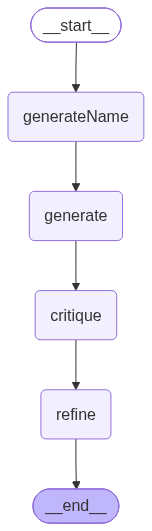

In [23]:
# Visualize the graph topology
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
# Run graph
result = app.invoke({"product_name": "MeetingMaster"})

print("***** Draft ****")
print(result["draft"])
print("***** Critique ****")
print(result["critique"])
print("**** Final Version ****")
print(result["final_copy"])

***** Draft ****
Introducing MeetingMaster, your intelligent virtual assistant designed to elevate your meeting experience. Seamlessly joining your scheduled calls, MeetingMaster listens attentively, capturing every detail with precision. It automatically transcribes conversations in real-time, ensuring no key point slips through the cracks, and highlights critical action items to keep your team on track.

With its advanced natural language processing capabilities, MeetingMaster generates comprehensive meeting summaries that are easy to review and share. Whether you're managing multiple projects or coordinating with remote teams, this AI-powered assistant simplifies follow-ups and accountability. Say goodbye to cumbersome note-taking and missed deadlines—MeetingMaster is your smart partner for productive, efficient meetings every time.
***** Critique ****
Certainly! Here's a detailed critique of the junior writer's product description across the three key areas:

**1. Clarity:**

- The

In [26]:
# Run graph after generate_productname
result = app.invoke({})

print("***** Draft ****")
print(result["draft"])
print("***** Critique ****")
print(result["critique"])
print("**** Final Version ****")
print(result["final_copy"])

***** Draft ****
Introducing MeetAI — your ultimate AI-powered meeting companion designed to streamline your collaboration and boost productivity. Seamlessly joining your virtual meetings, MeetAI listens attentively, capturing every important detail without interrupting the flow. From complex discussions to quick team check-ins, it ensures nothing slips through the cracks, allowing you to focus on what truly matters.

Beyond recording notes, MeetAI intelligently identifies action items, deadlines, and key decisions, organizing them automatically for easy follow-up. After each meeting, it sends comprehensive summaries directly to your inbox, highlighting next steps and responsibilities. With MeetAI, you can say goodbye to tedious note-taking and manual follow-ups, empowering your team to stay aligned, informed, and efficient every step of the way.
***** Critique ****
Thank you for sharing the product description. Here's my detailed critique based on clarity, tone, and persuasiveness:

*

In [ ]:
#Reducers: Is a way of updating the state without overriding it. Eg: add_messages
#Conditional edges: dynamic flow to required node based on given condition
#Memory with checkpoints: periodically saving your graph state as a checkpoint and retrieving it as needed